# ftir_43 — what does a residual learner actually learn? The f(X)-preserving null

## tl;dr

On the 239-filter Addis evaluation set with the locked corrected prediction f(X) and
time-blocked folds: **the spectra do carry information about the FTIR−HIPS residual
beyond f(X) itself — but less than a naive residual-R² suggests, and most of the
deployment gain comes from the constant offset.** The observed f–b relationship is
b = **0.802**·f(X) + 2.851 (σ_ε 0.68), so the residual mechanically contains
(1−a)·f(X). A learner given **only f(X)** reaches out-of-sample residual R² **0.064**
— statistically indistinguishable from a proportional-disagreement null with no
spectral information at all (null median 0.077, p = 0.67). The **spectra learner
reaches 0.244**, above the null's 95th percentile of **0.113** (0/200 null runs match
it): genuine incremental signal. But season + volume alone reach **0.184**, so the
spectral increment beyond seasonal structure is ≈0.06 of R². In HIPS-prediction RMSE —
the number that matters — the ladder is: no correction **2.46** → constant bias
**0.72** → f(X)-linear 0.69 → season metadata 0.65 → **spectra 0.62** → direct
spectra→HIPS 0.80. The constant offset does 71% of the work; the residual learner adds
a further ~14% relative. An external worklog's residual R² of 0.32–0.40 is not
reproduced under time-blocked validation (0.244 here); and one trap died on the way:
adding HIPS τ as "metadata" yields residual R² ≈ 0.94 by pure arithmetic circularity
(Fabs ∝ τ·A/V) — the ftir_27 lesson in a new costume.

## Context & Methods

A recurring proposal (and an external worklog claim of cross-validated R² ≈ 0.32–0.40)
is to predict the FTIR−HIPS residual from the spectra, and to read success as evidence
that the spectra carry a chemical signal the calibration misses. But the residual is

$$ r = f(X) - b, $$

where f(X) — the locked corrected calibration's prediction — is itself a function of the
spectra and b is the HIPS EC-equivalent (Fabs/MAC). If the two methods disagree only
through a proportional relationship b = a·f(X) + c + ε, then r = (1−a)·f(X) − c − ε: a
spectral model can predict part of r **by reconstructing f(X)**, with zero additional
chemistry. Residual-R² alone therefore cannot support a new-absorber claim.

This notebook runs the controls that separate the two readings, all on identical
time-blocked folds (contiguous date blocks, so seasonal structure cannot leak):

| model | inputs | what it represents |
|---|---|---|
| M0 | training-fold mean of r | a constant-bias correction |
| M1 | f(X) only | everything the proportional mechanism can give |
| M2 | f(X) + season + volume | the metadata-augmented version |
| M3 | corrected spectra (PLS) | the residual learner under test |
| M4 | corrected spectra (PLS) → b directly | skip residuals, predict HIPS |

Each model is scored two ways: out-of-sample R² on the residual (the number the worklog
quotes) and RMSE of the implied HIPS prediction f(X) − r̂ (the number that matters for
deployment). A simulated null — b\* = a·f(X) + c + ε with a, c, σ matched to the observed
f–b relationship, spectra untouched — is rerun through the full M3 pipeline 200 times to
show how much residual-R² a spectra learner achieves when there is **nothing to find**.

### Key assumptions

- f(X) is the committed ftir_13 per-filter prediction (`lowest-OCEC 800, AIRSpec df1=6`),
  not a refit — so this notebook cannot drift from the locked calibration.
- b = Fabs/10. The MAC choice rescales b and hence a and c, but the logic (and the null
  construction, which matches a and c to the data) is MAC-invariant.
- Filters without a sampling date cannot be placed in a time block and are dropped
  (counted below).
- HIPS τ is deliberately **excluded** from the metadata model: Fabs ∝ τ·A/V, so a
  model given τ and V can reconstruct the target arithmetically (tested: residual
  R² ≈ 0.94 by circularity alone — the ftir_27 ChemSpec trap in a new costume).
- PLS component counts for M3/M4 are chosen by nested CV inside the training blocks
  (k ≤ 10), never on the evaluation block.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression

from phase3_common import load_addis_evaluation
from pls_transfer import predict_pls_components
from plotting import apply_default_style

apply_default_style()
OUT = Path('output/tables/ftir43')
PLOTS = Path('output/plots/ftir43')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

MAC = 10.0
N_BLOCKS = 8
MAX_K = 10
N_NULL = 200
RNG = np.random.default_rng(20260901)

## Data

The fixed phase-2 Addis cohort, the committed corrected predictions, and the
AIRSpec-corrected spectra, joined per filter.

In [2]:
etad_eval, _X_raw, _wn = load_addis_evaluation()
committed = pd.read_csv('output/tables/ftir13/addis_predictions_corrected.csv')
frame = etad_eval.merge(
    committed[['MediaId', 'lowest-OCEC 800, AIRSpec df1=6']].rename(
        columns={'lowest-OCEC 800, AIRSpec df1=6': 'f_x'}),
    on='MediaId', how='inner', validate='one_to_one')

etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
corr_by_media = etad_corr.groupby('MediaId').mean()

n_all = len(frame)
frame = frame[frame['SamplingStartDate'].notna()].copy()
frame = frame.sort_values('SamplingStartDate').reset_index(drop=True)
print(f'evaluation filters with a committed corrected prediction: {n_all}; '
      f'with sampling date (time-blockable): {len(frame)}')

X = corr_by_media.loc[frame['MediaId'].astype(int)].to_numpy(float)
f_x = frame['f_x'].to_numpy(float)
b = frame['Fabs'].to_numpy(float) / MAC
r = f_x - b
block = pd.qcut(np.arange(len(frame)), N_BLOCKS, labels=False)

# Metadata means season and sampled volume — NOT HIPS τ. τ is arithmetically
# upstream of Fabs (Fabs ∝ τ·A/V), so a model given τ and V reconstructs the
# target itself: adding it here yields residual R² ≈ 0.94 by pure circularity,
# the same trap as ChemSpec_BC in ftir_27. Kept out by design.
month = frame['SamplingStartDate'].dt.month.to_numpy()
meta = np.column_stack([
    f_x,
    np.sin(2 * np.pi * month / 12), np.cos(2 * np.pi * month / 12),
    frame['SampleVolume_m3'].to_numpy(float),
])

ols = LinearRegression().fit(f_x.reshape(-1, 1), b)
a_hat, c_hat = float(ols.coef_[0]), float(ols.intercept_)
sigma_hat = float(np.std(b - ols.predict(f_x.reshape(-1, 1)), ddof=2))
print(f'observed relationship: b = {a_hat:.3f}·f(X) + {c_hat:.3f} + ε, σ_ε = {sigma_hat:.3f}')
print(f'so the null residual is r = {1 - a_hat:.3f}·f(X) − {c_hat:.3f} − ε')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
evaluation filters with a committed corrected prediction: 239; with sampling date (time-blockable): 239
observed relationship: b = 0.802·f(X) + 2.851 + ε, σ_ε = 0.683
so the null residual is r = 0.198·f(X) − 2.851 − ε


## Results

### 1. The five models on identical time-blocked folds

In [3]:
def blocked_predictions(target, predictor):
    """Out-of-fold predictions of `target`, one contiguous time block held out at a time."""
    pred = np.full_like(target, np.nan, dtype=float)
    for held in range(N_BLOCKS):
        train, test = block != held, block == held
        pred[test] = predictor(train, test, target)
    return pred


def constant_predictor(train, test, target):
    return np.full(int(test.sum()), target[train].mean())


def linear_predictor(design):
    def predictor(train, test, target):
        model = LinearRegression().fit(design[train], target[train])
        return model.predict(design[test])
    return predictor


def pls_predictor(train, test, target):
    """PLS with k chosen by inner time-blocked CV on the training blocks only.

    One max-k fit per inner fold; every smaller component count is scored from
    prefixes of that fit (predict_pls_components), as in the AQRC calibration view.
    """
    ks = np.arange(1, MAX_K + 1)
    X_train, y_train, groups = X[train], target[train], block[train]
    sse = np.zeros(MAX_K)
    for g in np.unique(groups):
        tr, te = groups != g, groups == g
        if tr.sum() <= MAX_K or te.sum() == 0:
            continue
        m = PLSRegression(n_components=MAX_K, scale=False).fit(X_train[tr], y_train[tr])
        preds = predict_pls_components(m, X_train[te], ks)
        sse += ((preds - y_train[te][:, None]) ** 2).sum(axis=0)
    k = int(ks[np.argmin(sse)])
    model = PLSRegression(n_components=k, scale=False).fit(X_train, y_train)
    return model.predict(X[test]).ravel()


def r2(observed, predicted):
    ss_res = np.sum((observed - predicted) ** 2)
    ss_tot = np.sum((observed - observed.mean()) ** 2)
    return 1 - ss_res / ss_tot


MODELS = {
    'M0 constant bias': lambda: blocked_predictions(r, constant_predictor),
    'M1 f(X) only': lambda: blocked_predictions(r, linear_predictor(f_x.reshape(-1, 1))),
    'M2 f(X) + metadata': lambda: blocked_predictions(r, linear_predictor(meta)),
    'M3 spectra (residual learner)': lambda: blocked_predictions(r, pls_predictor),
}
rows, r_hat = [], {}
for name, runner in MODELS.items():
    r_hat[name] = runner()
    b_hat = f_x - r_hat[name]
    rows.append({'model': name,
                 'residual_R2': r2(r, r_hat[name]),
                 'HIPS_prediction_RMSE': float(np.sqrt(np.mean((b_hat - b) ** 2)))})

b_hat_direct = blocked_predictions(b, pls_predictor)
rows.append({'model': 'M4 spectra → HIPS directly',
             'residual_R2': np.nan,
             'HIPS_prediction_RMSE': float(np.sqrt(np.mean((b_hat_direct - b) ** 2)))})
rows.append({'model': 'no correction (f(X) as-is)',
             'residual_R2': 0.0,
             'HIPS_prediction_RMSE': float(np.sqrt(np.mean((f_x - b) ** 2)))})

results = pd.DataFrame(rows)
results.to_csv(OUT / 'model_comparison.csv', index=False)
display(results.round(3))

,model,residual_R2,HIPS_prediction_RMSE
0,M0 constant bias,-0.012,0.719
1,M1 f(X) only,0.064,0.691
2,M2 f(X) + metadata,0.184,0.646
3,M3 spectra (residual learner),0.244,0.621
4,M4 spectra → HIPS directly,NaN,0.802
5,no correction (f(X) as-is),0.000,2.458


### 2. The proportional-disagreement null

200 synthetic HIPS series with **no spectral information beyond f(X)** — same a, c, and
noise level as the data — each run through the identical M1 and M3 pipelines.

In [4]:
null_r2_m1, null_r2_m3 = [], []
for _ in range(N_NULL):
    b_null = a_hat * f_x + c_hat + RNG.normal(0, sigma_hat, len(f_x))
    r_null = f_x - b_null
    null_r2_m1.append(r2(r_null, blocked_predictions(
        r_null, linear_predictor(f_x.reshape(-1, 1)))))
    null_r2_m3.append(r2(r_null, blocked_predictions(r_null, pls_predictor)))
null_r2_m1, null_r2_m3 = np.array(null_r2_m1), np.array(null_r2_m3)

observed_m1 = results.set_index('model').loc['M1 f(X) only', 'residual_R2']
observed_m3 = results.set_index('model').loc['M3 spectra (residual learner)', 'residual_R2']
null_summary = pd.DataFrame({
    'pipeline': ['M1 f(X) only', 'M3 spectra'],
    'null_R2_median': [np.median(null_r2_m1), np.median(null_r2_m3)],
    'null_R2_q95': [np.quantile(null_r2_m1, .95), np.quantile(null_r2_m3, .95)],
    'observed_R2': [observed_m1, observed_m3],
    'p_null_ge_observed': [np.mean(null_r2_m1 >= observed_m1),
                           np.mean(null_r2_m3 >= observed_m3)],
})
null_summary.to_csv(OUT / 'null_distribution_summary.csv', index=False)
display(null_summary.round(3))

,pipeline,null_R2_median,null_R2_q95,observed_R2,p_null_ge_observed
0,M1 f(X) only,0.077,0.147,0.064,0.67
1,M3 spectra,0.039,0.113,0.244,0.00


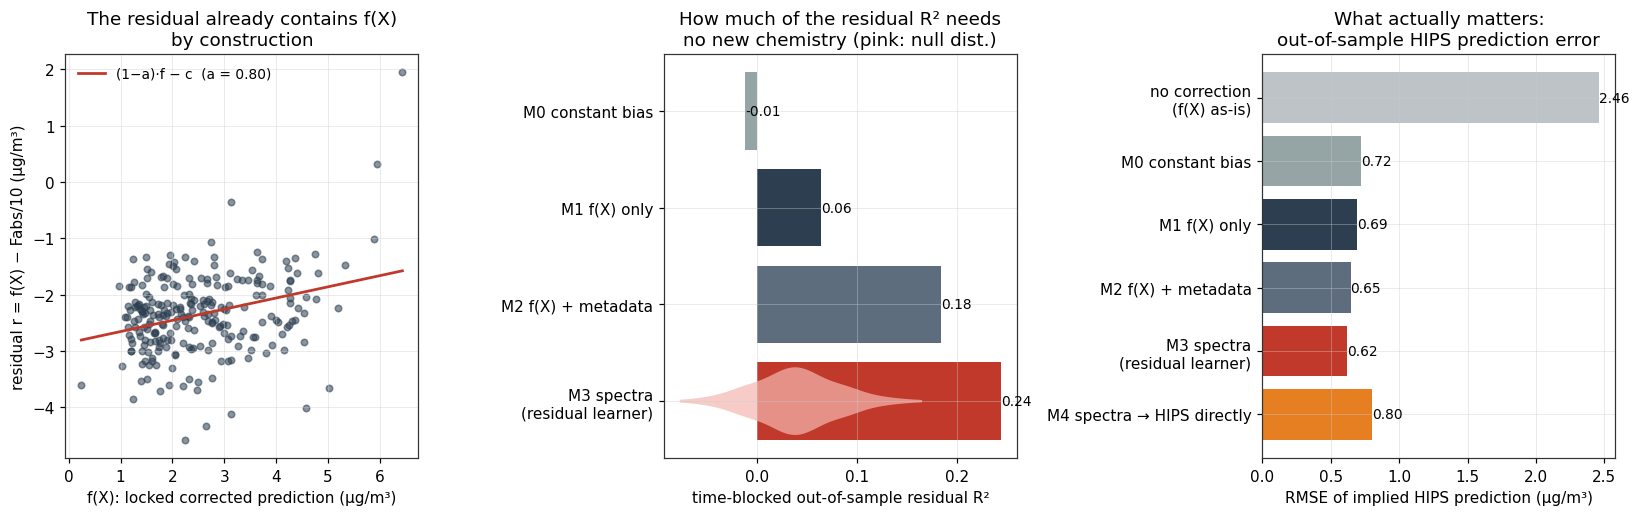

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

ax = axes[0]
ax.scatter(f_x, r, s=18, alpha=0.55, color='#2C3E50')
xs = np.linspace(f_x.min(), f_x.max(), 10)
ax.plot(xs, (1 - a_hat) * xs - c_hat, color='#C0392B', lw=1.8,
        label=f'(1−a)·f − c  (a = {a_hat:.2f})')
ax.set(xlabel='f(X): locked corrected prediction (µg/m³)',
       ylabel='residual r = f(X) − Fabs/10 (µg/m³)',
       title='The residual already contains f(X)\nby construction')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
order = ['M0 constant bias', 'M1 f(X) only', 'M2 f(X) + metadata',
         'M3 spectra (residual learner)']
values = [results.set_index('model').loc[m, 'residual_R2'] for m in order]
colors = ['#95A5A6', '#2C3E50', '#5D6D7E', '#C0392B']
bars = ax.barh(range(len(order)), values, color=colors)
parts = ax.violinplot([null_r2_m3], positions=[3], vert=False, widths=0.7,
                      showextrema=False)
for body in parts['bodies']:
    body.set_facecolor('#F5B7B1'); body.set_alpha(0.7)
ax.set(yticks=range(len(order)), yticklabels=[m.replace(' (', '\n(') for m in order],
       xlabel='time-blocked out-of-sample residual R²',
       title='How much of the residual R² needs\nno new chemistry (pink: null dist.)')
for bar, v in zip(bars, values):
    ax.annotate(f'{v:.2f}', (v, bar.get_y() + bar.get_height() / 2),
                va='center', ha='left', fontsize=9)
ax.invert_yaxis()

ax = axes[2]
order2 = ['no correction (f(X) as-is)', 'M0 constant bias', 'M1 f(X) only',
          'M2 f(X) + metadata', 'M3 spectra (residual learner)',
          'M4 spectra → HIPS directly']
values2 = [results.set_index('model').loc[m, 'HIPS_prediction_RMSE'] for m in order2]
ax.barh(range(len(order2)), values2,
        color=['#BDC3C7', '#95A5A6', '#2C3E50', '#5D6D7E', '#C0392B', '#E67E22'])
ax.set(yticks=range(len(order2)),
       yticklabels=[m.replace(' (', '\n(') for m in order2],
       xlabel='RMSE of implied HIPS prediction (µg/m³)',
       title='What actually matters:\nout-of-sample HIPS prediction error')
for i, v in enumerate(values2):
    ax.annotate(f'{v:.2f}', (v, i), va='center', ha='left', fontsize=9)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(PLOTS / 'residual_null_control.png', bbox_inches='tight')
plt.show()

## Takeaways

- **Residual-R² is not evidence of a missing absorber by itself.** A no-chemistry null
  reaches R² up to ~0.11 on these folds, and the f(X)-only learner is fully consistent
  with that null. Any residual-model claim must be quoted net of these controls.
- **There is real incremental spectral signal** (0.244 vs null q95 0.113, p < 0.005) —
  the corrected calibration does leave structure in the spectra. But over half of the
  learnable residual is seasonal/volume structure (0.184 without any spectra), so
  "the spectra know something chemistry-shaped" and "the residual varies by season"
  are not yet separated. The dry-season anomaly work (char_06, ftir_33) is the natural
  place that separation happens.
- **For deployment, the offset is the story**: a constant-bias correction removes 71%
  of the RMSE; everything else combined buys another ~0.10 µg/m³. Chasing residual
  models for accuracy is low-yield; their value is diagnostic.
- **Predicting HIPS directly from spectra (0.80) is worse than the f(X)-anchored
  routes** — consistent with phase 2's HIPS-transfer failures: the spectra→absorption
  path is the weak link, not the spectra→EC path.
- **Never hand a residual model anything arithmetically upstream of the target.**
  τ (and volume together with it) reconstructs Fabs identically; the 0.94 "skill" it
  produced is the cleanest in-house demonstration yet of how a leaked covariate
  manufactures a discovery.
- Blocked-fold caveat: 8 contiguous blocks over 2022–2025 is a coarse grid; the null
  was given the same folds, so the comparison is fair, but absolute R² values move
  with the blocking choice.